# Week 3 · Lecture 1 — Metropolis–Hastings from Scratch

## Learning objectives

1. State the goal of MCMC: producing samples from $p(\theta \mid \mathcal{D})$ when only $\tilde p(\theta) \propto p(\theta \mid \mathcal{D})$ is computable.
2. Implement the **Metropolis–Hastings** (MH) algorithm in NumPy.
3. Prove (and verify empirically) that the MH chain has the target as its stationary distribution.
4. Diagnose convergence with **trace plots**, **autocorrelation**, **effective sample size (ESS)**, and Gelman–Rubin $\hat{R}$.

## 1. Why MCMC at all?

For exponential-family models with conjugate priors (Week 1) the posterior is closed form. Beyond that — non-conjugate likelihoods, hierarchical models, neural-network priors — we cannot evaluate the normalising constant $p(\mathcal{D}) = \int p(\mathcal{D} \mid \theta) p(\theta) d\theta$. But we can evaluate

$$
\tilde p(\theta) \;=\; p(\mathcal{D} \mid \theta)\, p(\theta) \;\propto\; p(\theta \mid \mathcal{D}).
$$

MCMC constructs a Markov chain whose stationary distribution is $p(\theta \mid \mathcal{D})$, using only $\tilde p$. After a burn-in period, chain states are (correlated) samples from the posterior.

## 2. The Metropolis–Hastings algorithm

Pick any proposal density $q(\theta' \mid \theta)$ from which we can sample. At each step:

1. Propose $\theta' \sim q(\cdot \mid \theta_t)$.
2. Compute the **acceptance probability**
$$
\alpha = \min\!\left(1,\ \frac{\tilde p(\theta')}{\tilde p(\theta_t)} \cdot \frac{q(\theta_t \mid \theta')}{q(\theta' \mid \theta_t)}\right).
$$
3. With probability $\alpha$, set $\theta_{t+1} = \theta'$; otherwise $\theta_{t+1} = \theta_t$.

The key identity is **detailed balance**: $p(\theta) T(\theta \to \theta') = p(\theta') T(\theta' \to \theta)$, which forces $p$ to be the stationary distribution. The proof is a one-liner: substitute the MH transition kernel and observe the cancellation.

When $q$ is symmetric ($q(\theta' \mid \theta) = q(\theta \mid \theta')$, e.g.\ a Gaussian random walk), the proposal ratio drops out and we get the original *Metropolis* algorithm:

$$
\alpha = \min\!\left(1,\ \frac{\tilde p(\theta')}{\tilde p(\theta_t)}\right).
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(0)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
def metropolis_hastings(log_target, theta0, n_samples, proposal_scale=1.0, rng=None):
    # Symmetric Gaussian random-walk Metropolis. log_target returns log tilde p(theta).
    rng = rng or np.random.default_rng(0)
    theta = np.array(theta0, dtype=float)
    D = theta.shape[0] if theta.ndim > 0 else 1
    chain = np.empty((n_samples, D))
    log_p_curr = log_target(theta)
    n_accept = 0

    for t in range(n_samples):
        theta_prop = theta + rng.normal(0, proposal_scale, size=D)
        log_p_prop = log_target(theta_prop)
        log_alpha = log_p_prop - log_p_curr
        if np.log(rng.uniform()) < log_alpha:
            theta = theta_prop
            log_p_curr = log_p_prop
            n_accept += 1
        chain[t] = theta

    accept_rate = n_accept / n_samples
    return chain, accept_rate


## 3. Test 1: a 1D bimodal target

Sample from $p(\theta) \propto 0.3\, \mathcal{N}(\theta \mid -2, 1) + 0.7\, \mathcal{N}(\theta \mid 3, 1.5^2)$. Notice we deliberately use a target only available up to a constant in `log_target`.


Acceptance rate: 0.628


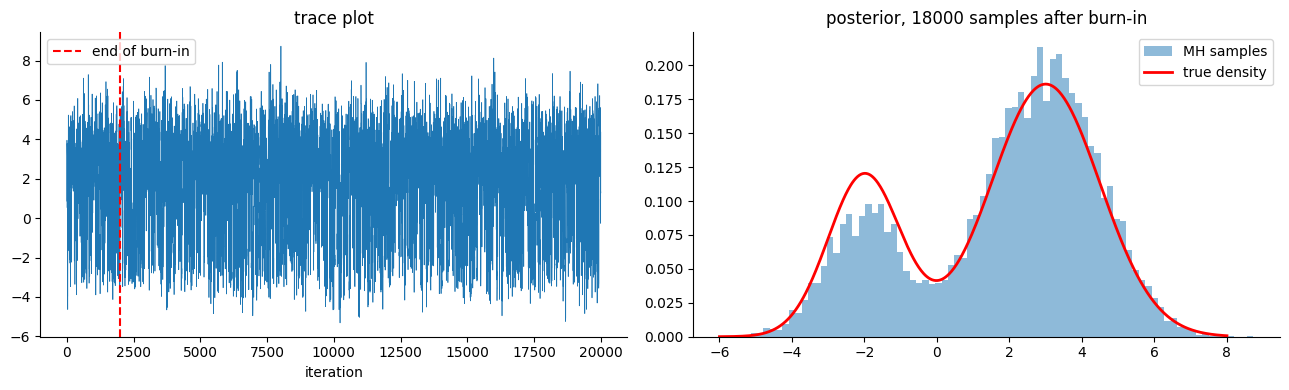

In [3]:
def log_bimodal(theta):
    t = theta[0] if theta.ndim > 0 else theta
    # log of unnormalised mixture
    log_p1 = -0.5 * (t + 2)**2          # N(-2, 1)
    log_p2 = -0.5 * (t - 3)**2 / 1.5**2 # N(3, 1.5^2)
    return np.logaddexp(np.log(0.3) + log_p1, np.log(0.7) + log_p2)

chain, acc = metropolis_hastings(log_bimodal, [0.0], n_samples=20_000, proposal_scale=2.5,
                                   rng=np.random.default_rng(1))
print(f"Acceptance rate: {acc:.3f}")

burn = 2000
samples = chain[burn:, 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(chain[:, 0], lw=0.5)
axes[0].axvline(burn, color="red", ls="--", label="end of burn-in")
axes[0].set_title("trace plot"); axes[0].set_xlabel("iteration"); axes[0].legend()

t_grid = np.linspace(-6, 8, 600)
true_density = 0.3 * stats.norm.pdf(t_grid, -2, 1) + 0.7 * stats.norm.pdf(t_grid, 3, 1.5)
axes[1].hist(samples, bins=80, density=True, alpha=0.5, label="MH samples")
axes[1].plot(t_grid, true_density, "r-", lw=2, label="true density")
axes[1].set_title(f"posterior, {len(samples)} samples after burn-in"); axes[1].legend()

plt.tight_layout(); plt.show()


The histogram matches both modes. With a small proposal scale the chain would stay trapped in one mode for huge stretches; with a large one most proposals would be rejected. Tuning the proposal is the recurring practical challenge in MH.

## 4. Test 2: a 2D Bayesian logistic posterior

We sample from the Bayesian logistic posterior of Week 2 (Lecture 3) and compare against the Laplace approximation.


In [4]:
from sklearn.datasets import make_classification
from scipy.special import expit

X, y = make_classification(n_samples=80, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, class_sep=1.5, random_state=42)
Phi = np.hstack([np.ones((X.shape[0], 1)), X])  # bias + 2 features

def log_posterior_logreg(w, prior_var=4.0):
    a = Phi @ w
    log_lik = np.sum(y * a - np.logaddexp(0, a))
    log_prior = -0.5 * (w @ w) / prior_var
    return log_lik + log_prior

chain_lr, acc_lr = metropolis_hastings(log_posterior_logreg, np.zeros(3),
                                        n_samples=30_000, proposal_scale=0.4,
                                        rng=np.random.default_rng(2))
print(f"Acceptance rate: {acc_lr:.3f}")
burn = 3000
post = chain_lr[burn:]
print(f"Posterior mean: {post.mean(0)}")
print(f"Posterior std : {post.std(0)}")


Acceptance rate: 0.651
Posterior mean: [ 1.38714377 -0.30059949  4.23217464]
Posterior std : [1.19641336 0.96832704 0.96402237]


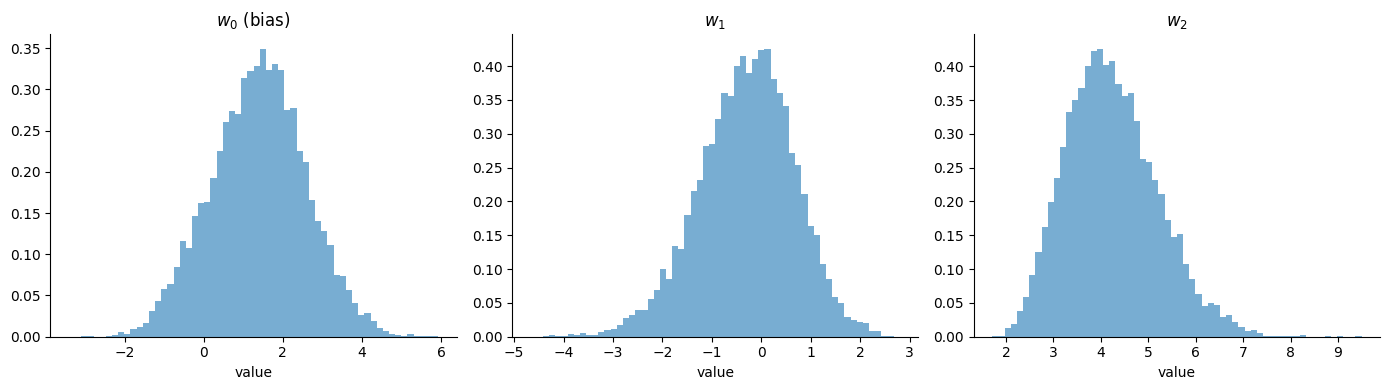

In [5]:
import scipy.stats
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = [r"$w_0$ (bias)", r"$w_1$", r"$w_2$"]
for j, ax in enumerate(axes):
    ax.hist(post[:, j], bins=60, density=True, alpha=0.6)
    ax.set_title(labels[j])
    ax.set_xlabel("value")
plt.tight_layout(); plt.show()


## 5. Diagnostics

A bag of samples is useless without diagnostics. The four we cover are:

### 5.1 Trace plots
A trace plot shows $\theta^{(t)}$ vs $t$. A healthy chain looks like white noise with a stable mean. Drift, level shifts, or "hairy caterpillar" features that change character indicate non-convergence.

### 5.2 Autocorrelation
Successive MH samples are correlated. The autocorrelation function

$$
\rho_k = \frac{\mathrm{Cov}(\theta^{(t)}, \theta^{(t+k)})}{\mathrm{Var}(\theta^{(t)})}
$$

decays geometrically for a good chain. Slow decay $\Rightarrow$ chain is mixing badly.

### 5.3 Effective sample size (ESS)
With $N$ MCMC samples and integrated autocorrelation time $\tau_{\text{int}} = 1 + 2 \sum_{k \geq 1} \rho_k$, the effective sample size is

$$
\text{ESS} = \frac{N}{\tau_{\text{int}}}.
$$

ESS estimates how many *iid* draws our $N$ correlated draws are equivalent to. ESS / N is the chain's *efficiency*.

### 5.4 Gelman–Rubin $\hat R$
Run multiple chains from different initial states. Compare within-chain variance $W$ to between-chain variance $B$. Define

$$
\hat R = \sqrt{\frac{(N-1)/N \cdot W + B/N}{W}}.
$$

$\hat R \approx 1$ for converged chains; $\hat R > 1.1$ is a red flag.


$w_0$ (bias): tau_int =   83.1    ESS =    324.9 of 27000 (1.20%)
$w_1$: tau_int =   73.6    ESS =    366.9 of 27000 (1.36%)
$w_2$: tau_int =   54.2    ESS =    498.2 of 27000 (1.85%)


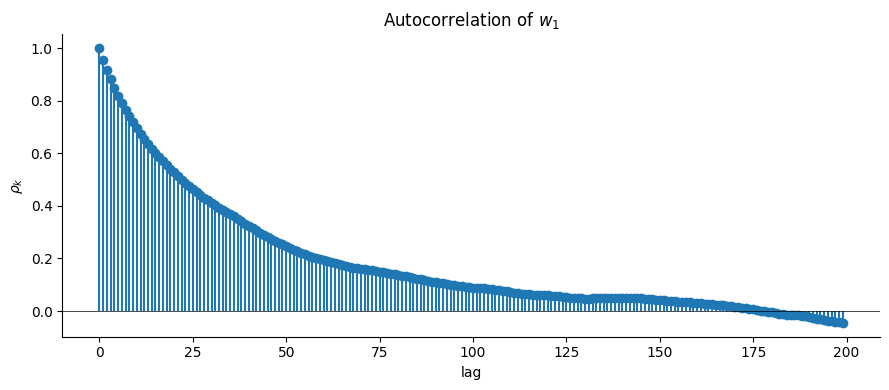

In [6]:
def autocorrelation(x, max_lag=200):
    x = np.asarray(x) - np.mean(x)
    var = np.var(x)
    n = len(x)
    rho = np.array([np.mean(x[:n-k] * x[k:]) / var for k in range(max_lag)])
    return rho

def ess(x, max_lag=500):
    rho = autocorrelation(x, max_lag=max_lag)
    # Geyer's initial monotone sequence: sum positive autocorrelations until first negative
    tau = 1 + 2 * np.sum(rho[1:][rho[1:] > 0])
    return len(x) / tau, tau

# ESS for each parameter
for j, lbl in enumerate(labels):
    e, tau = ess(post[:, j])
    print(f"{lbl}: tau_int = {tau:6.1f}    ESS = {e:8.1f} of {len(post)} ({100*e/len(post):.2f}%)")

# Autocorrelation plot for w_1
rho = autocorrelation(post[:, 1], max_lag=200)
fig, ax = plt.subplots(figsize=(9, 4))
ax.stem(np.arange(len(rho)), rho, basefmt=" ")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Autocorrelation of $w_1$"); ax.set_xlabel("lag"); ax.set_ylabel(r"$\rho_k$")
plt.tight_layout(); plt.show()


In [7]:
# Gelman-Rubin: 4 chains from different inits
def gelman_rubin(chains):
    # chains: (n_chains, n_samples, D) or (n_chains, n_samples)
    chains = np.asarray(chains)
    if chains.ndim == 2:
        chains = chains[:, :, None]
    M, N, D = chains.shape
    chain_means = chains.mean(axis=1)
    overall_mean = chain_means.mean(axis=0)
    B = N / (M - 1) * np.sum((chain_means - overall_mean)**2, axis=0)
    W = np.mean(chains.var(axis=1, ddof=1), axis=0)
    var_hat = (N - 1) / N * W + B / N
    return np.sqrt(var_hat / W)

inits = [np.array([-1, -1, -1]), np.array([1, 1, 1]),
         np.array([-1, 1, -1]), np.array([1, -1, 1])]
chains = []
for init in inits:
    c, _ = metropolis_hastings(log_posterior_logreg, init, n_samples=10_000,
                                proposal_scale=0.4, rng=np.random.default_rng(int(init.sum() + 100)))
    chains.append(c[2000:])
chains = np.stack(chains)
r_hat = gelman_rubin(chains)
for lbl, r in zip(labels, r_hat):
    print(f"{lbl}: R_hat = {r:.4f}")


$w_0$ (bias): R_hat = 1.0085
$w_1$: R_hat = 1.0046
$w_2$: R_hat = 1.0019


## 6. Take-aways

- MH samples from any density known up to a constant. The price: correlated samples and a tuning problem (proposal scale).
- Always inspect trace plots and ESS *before* trusting MCMC output.
- For low dimensions and well-tuned proposals MH is fine. In high dimensions or with anisotropic posteriors it mixes terribly — we will fix this with HMC.

## 7. Exercises

**Exercise 3.1.** Prove that MH satisfies detailed balance with respect to $p(\theta)$.

**Exercise 3.2 (Proposal-scale tuning).** For the bimodal example, sweep proposal scale from 0.1 to 10 and plot acceptance rate vs scale. What is the "optimal" range, and how do textbook rules of thumb (acceptance $\approx 0.234$ in high-D, $0.44$ in 1D) align with the rate that maximises ESS?

**Exercise 3.3 (Independence MH).** Replace the random walk by an *independence* proposal $q(\theta') = q(\theta')$. What can go wrong? Construct a 1D target where the independence MH chain fails badly.

**Exercise 3.4 (Adaptive MH).** Implement an *adaptive* MH that updates the proposal covariance to match the empirical sample covariance. (Note: naive adaptation violates the Markov property; the Andrieu-Thoms 2008 framework gives correct adaptive schemes.)
